In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sp
import scipy.constants as cte
import math

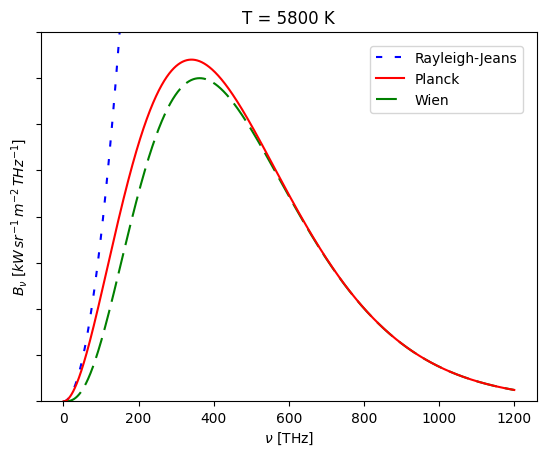

In [9]:
h = 6.62607e-34
c = 2.99792e8
kB = 1.38065e-23
T = 5800

def planck(nu, T):
    f = nu * 1e12
    if f == 0.0 or h * f / (kB * T) > 1e2:
        return 0.0
    return 2 * h * f**3 / c**2 / (np.exp(h * f / (kB * T)) - 1.0)

def wien(nu, T):
    f = nu * 1e12
    if h * f / (kB * T) > 1e2:
        return 0.0
    return 2 * h * f**3 / c**2 * np.exp(-h * f / (kB * T))

def rayleigh_jeans(nu, T):
    f = nu * 1e12
    return 2 * f**2 * kB * T / c**2

x = np.linspace(0, 1200, 8001)
y_planck = [planck(xx, T) * 1e9 for xx in x]
y_wien = [wien(xx, T) * 1e9 for xx in x]

y_rj = [rayleigh_jeans(xx, T) * 1e9 for xx in x]
pp, = plt.plot(x, y_planck, '-', label='Planck', zorder=-1, color = 'red')
pw, = plt.plot(x, y_wien, '--', dashes=[10, 4], label='Wien', zorder=-2, color = 'green')
pr, = plt.plot(x, y_rj, ':', dashes=[3, 6], label='Rayleigh-Jeans', zorder=-3, color = 'blue')

plt.xlabel(r'$\nu$ [THz]')
plt.ylabel(r'$B_{\nu}\;[kW\,sr^{-1}\,m^{-2}\,THz^{-1}]$')
plt.ylim(0, 40)
plt.tick_params(labelleft = False)
plt.title('T = 5800 K')
plt.legend([pr, pp, pw], ['Rayleigh-Jeans', 'Planck', 'Wien'],
           loc='upper right', borderaxespad=1)
plt.savefig('planckrjw.png')
plt.show()

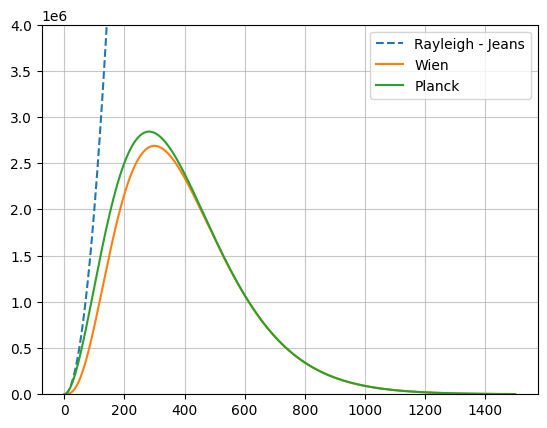

In [18]:
v = np.linspace(0.01, 1500, 10000)
k = 1
c = 1
h = 1
T = 100
RJ = 2 * k * T * v ** 2 / c ** 2
Wien = 2 * h * v ** 3 * np.exp(- h * v / (k * T)) / c ** 2
Planck = 2 * h * v ** 3 / (c ** 2 * (np.exp(h * v / (k * T)) - 1))
plt.plot(v, RJ, '--', label = 'Rayleigh - Jeans', )
plt.plot(v, Wien, label = 'Wien')
plt.plot(v, Planck, label ='Planck')
plt.legend()
plt.grid(alpha = 0.70)
plt.ylim(0, 4e6)
plt.show()


In [118]:
x = np.linspace(-5, 5, 1000)
clpdf = 1 / (np.pi * np.sqrt(5.1 ** 2 - x ** 2))
n = np.array([5, 10, 15, 20])
a = (1 / np.pi) ** 0.25 / np.sqrt(2 ** n * sp.gamma(n + 1))
herm5 =  sp.eval_hermite(n[0], x)
herm10 = sp.eval_hermite(n[1], x)
herm15 = sp.eval_hermite(n[2], x)
herm20 = sp.eval_hermite(n[3], x)
y1 = (a[0] * herm5 * np.exp(-x**2 / 2)) ** 2
y2 = (a[1] * herm10 * np.exp(-x**2 / 2)) ** 2
y3 = (a[2] * herm15 * np.exp(-x**2 / 2)) ** 2
y4 = (a[3] * herm20 * np.exp(-x**2 / 2)) ** 2
"""
y1 = (1 / cte.hbar) ** 0.25 * herm5(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))
y2 = (1 / cte.hbar) ** 0.25 * herm10(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))
y3 = (1 / cte.hbar) ** 0.25 * herm15(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))
y4 = (1 / cte.hbar) ** 0.25 * herm20(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))
"""

'\ny1 = (1 / cte.hbar) ** 0.25 * herm5(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))\ny2 = (1 / cte.hbar) ** 0.25 * herm10(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))\ny3 = (1 / cte.hbar) ** 0.25 * herm15(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))\ny4 = (1 / cte.hbar) ** 0.25 * herm20(x / np.sqrt(cte.hbar)) ** 2 * np.exp(- x ** 2 / (2 * cte.hbar))\n'

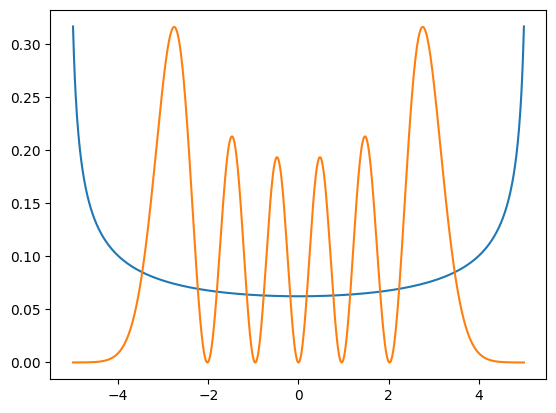

In [122]:
plt.plot(x, clpdf)
plt.plot(x, y1)

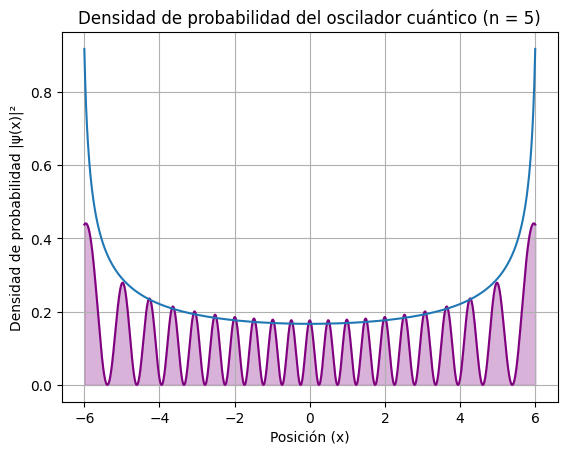

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, gamma

n = 20
x = np.linspace(-6, 6, 1000)
x2 = np.linspace(-5.9, 5.9, 1000)
pdf = 1 / (np.sqrt(6 ** 2 - x2**2))

H = hermite(n)
N = 1.0 / np.sqrt((2** n) * gamma(1 + n))
psi = N * np.exp(-x**2 / 2.0) * H(x)
densidad = psi**2

fig, ax = plt.subplots(2,2, figsize = (6, 6), sharey = True, sharex = True)
fig.supylabel('Densidad de probabilidad |ψ(x)|²')
fig.supxlabel('Momento (p)')
ax[0, 0].plot(x, densidad, color='purple', label = 'n = 5')
ax[0, 0].plot(x, pdf)
ax[0, 0].grid(True)
ax[0, 0].fill_between(x, densidad, alpha=0.3, color='purple')
ax[0, 1]
ax[1, 0]
ax[1, 1]

plt.plot(x, densidad, color='purple')

plt.title('Densidad de probabilidad del oscilador cuántico (n = 5)')
plt.xlabel('Momento (p)')
plt.ylabel('Densidad de probabilidad |ψ(x)|²')
plt.grid(True)
plt.fill_between(x, densidad, alpha=0.3, color='purple')
plt.show()

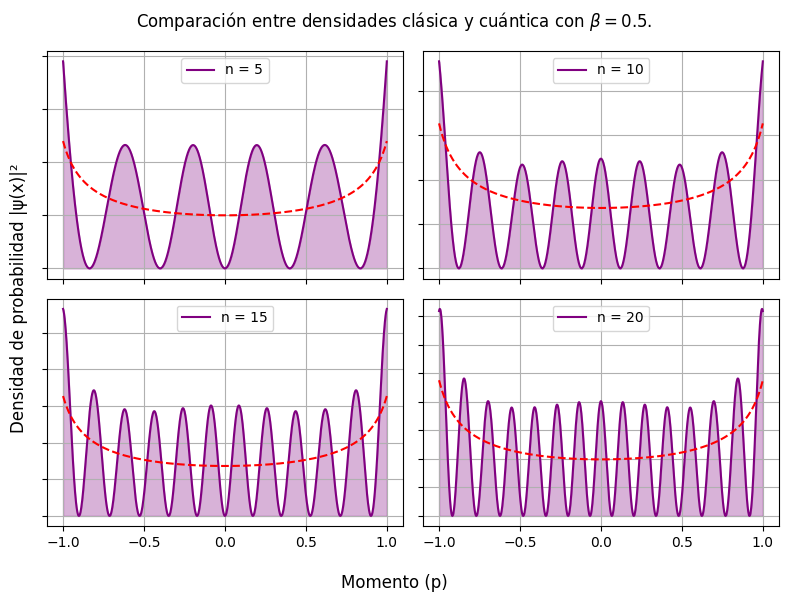

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite, gamma, gegenbauer

gam = 2
beta = 0.5
lamb = gam / beta
delta = lamb
alpha = delta - beta
x = np.linspace(-1, 1, 1000)
x2 = np.linspace(-1, 1, 1000)

H1 = gegenbauer(5, alpha, monic=False)
H2 = gegenbauer(10, alpha, monic=False)
H3 = gegenbauer(15, alpha, monic=False)
H4 = gegenbauer(20, alpha, monic=False)
pdf1 = 55 / (np.sqrt((1.1) ** 2 - x2**2))
pdf2 = 750 / (np.sqrt((1.1) ** 2 - x2**2))
pdf3 = 3000 / (np.sqrt((1.1) ** 2 - x2**2))
pdf4 = 10900 / (np.sqrt((1.1) ** 2 - x2**2))

psi1 = (1 + beta * x ** 2) ** (- delta) * H1(x / np.sqrt(1 + beta * x ** 2)) 
psi2 = (1 + beta * x ** 2) ** (- delta) *H2(x / np.sqrt(1 + beta * x ** 2)) 
psi3 = (1 + beta * x ** 2) ** (- delta) *H3(x / np.sqrt(1 + beta * x ** 2)) 
psi4 = (1 + beta * x ** 2) ** (- delta) *H4(x / np.sqrt(1 + beta * x ** 2)) 
densidad1 = psi1**2
densidad2 = psi2**2
densidad3 = psi3**2
densidad4 = psi4**2




fig, ax = plt.subplots(2,2, figsize = (8, 6), sharex = True)
fig.supylabel('Densidad de probabilidad |ψ(x)|²')
fig.suptitle(r'Comparación entre densidades clásica y cuántica con $\beta = 0.5$.')
fig.supxlabel('Momento (p)')
ax[0, 0].plot(x, densidad1, color='purple', label = 'n = 5')
ax[0, 0].plot(x, pdf1, '--', color = 'red')
ax[0, 0].grid(True)
ax[0, 0].legend()
ax[0, 0].tick_params(labelleft = False)
ax[0, 0].fill_between(x, densidad1, alpha=0.3, color='purple')
ax[0, 1].plot(x, densidad2, color='purple', label = 'n = 10')
ax[0, 1].plot(x, pdf2, '--', color = 'red')
ax[0, 1].grid(True)
ax[0, 1].tick_params(labelleft = False)
ax[0, 1].legend()
ax[0, 1].fill_between(x, densidad2, alpha=0.3, color='purple')
ax[1, 0].plot(x, densidad3, color='purple', label = 'n = 15')
ax[1, 0].plot(x, pdf3, '--', color = 'red')
ax[1, 0].grid(True)
ax[1, 0].legend()
ax[1, 0].tick_params(labelleft = False)
ax[1, 0].fill_between(x, densidad3, alpha=0.3, color='purple')
ax[1, 1].plot(x, densidad4, color='purple', label = 'n = 20')
ax[1, 1].plot(x, pdf4, '--', color = 'red')
ax[1, 1].grid(True)
ax[1, 1].tick_params(labelleft = False)
ax[1, 1].legend()
ax[1, 1].fill_between(x, densidad4, alpha=0.3, color='purple')
plt.tight_layout()
"""
plt.plot(x, densidad, color='purple')
plt.plot(x, pdf, '--', color = 'red', )

plt.title('Densidad de probabilidad del oscilador cuántico (n = 5)')
plt.xlabel('Momento (p)')
plt.ylabel('Densidad de probabilidad |ψ(x)|²')
plt.grid(True)
plt.fill_between(x, densidad, alpha=0.3, color='purple')
"""
plt.show()

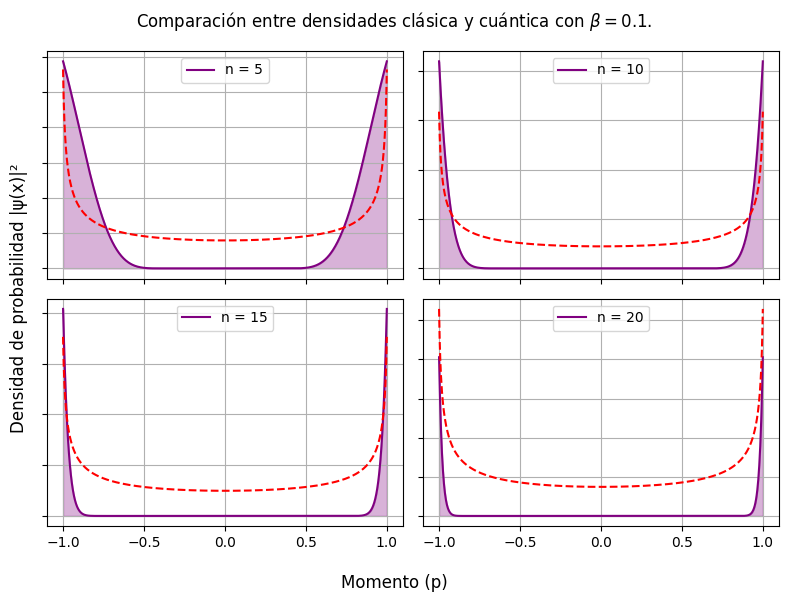

In [21]:
gam = 2
beta = 0.1
lamb = gam / beta
delta = lamb
alpha = delta - beta
x = np.linspace(-1, 1, 1000)
x2 = np.linspace(-1, 1, 1000)

H1 = gegenbauer(5, alpha, monic=False)
H2 = gegenbauer(10, alpha, monic=False)
H3 = gegenbauer(15, alpha, monic=False)
H4 = gegenbauer(20, alpha, monic=False)
pdf1 = 2e9 / (np.sqrt((1.01) ** 2 - x2**2))
pdf2 = 4.5e16 / (np.sqrt((1.01) ** 2 - x2**2))
pdf3 = 2.5e22/ (np.sqrt((1.01) ** 2 - x2**2))
pdf4 = 1.5e27 / (np.sqrt((1.01) ** 2 - x2**2))

psi1 = (1 + beta * x ** 2) ** (- delta) * H1(x / np.sqrt(1 + beta * x ** 2)) 
psi2 = (1 + beta * x ** 2) ** (- delta) *H2(x / np.sqrt(1 + beta * x ** 2)) 
psi3 = (1 + beta * x ** 2) ** (- delta) *H3(x / np.sqrt(1 + beta * x ** 2)) 
psi4 = (1 + beta * x ** 2) ** (- delta) *H4(x / np.sqrt(1 + beta * x ** 2)) 
densidad1 = psi1**2
densidad2 = psi2**2
densidad3 = psi3**2
densidad4 = psi4**2

fig, ax = plt.subplots(2,2, figsize = (8, 6), sharex = True)
fig.supylabel('Densidad de probabilidad |ψ(x)|²')
fig.suptitle(r'Comparación entre densidades clásica y cuántica con $\beta = 0.1$.')
fig.supxlabel('Momento (p)')
ax[0, 0].plot(x, densidad1, color='purple', label = 'n = 5')
ax[0, 0].plot(x, pdf1, '--', color = 'red')
ax[0, 0].grid(True)
ax[0, 0].legend()
ax[0, 0].tick_params(labelleft = False)
ax[0, 0].fill_between(x, densidad1, alpha=0.3, color='purple')
ax[0, 1].plot(x, densidad2, color='purple', label = 'n = 10')
ax[0, 1].plot(x, pdf2, '--', color = 'red')
ax[0, 1].grid(True)
ax[0, 1].tick_params(labelleft = False)
ax[0, 1].legend()
ax[0, 1].fill_between(x, densidad2, alpha=0.3, color='purple')
ax[1, 0].plot(x, densidad3, color='purple', label = 'n = 15')
ax[1, 0].plot(x, pdf3, '--', color = 'red')
ax[1, 0].grid(True)
ax[1, 0].legend()
ax[1, 0].tick_params(labelleft = False)
ax[1, 0].fill_between(x, densidad3, alpha=0.3, color='purple')
ax[1, 1].plot(x, densidad4, color='purple', label = 'n = 20')
ax[1, 1].plot(x, pdf4, '--', color = 'red')
ax[1, 1].grid(True)
ax[1, 1].tick_params(labelleft = False)
ax[1, 1].legend()
ax[1, 1].fill_between(x, densidad4, alpha=0.3, color='purple')
plt.tight_layout()
"""
plt.plot(x, densidad, color='purple')
plt.plot(x, pdf, '--', color = 'red', )

plt.title('Densidad de probabilidad del oscilador cuántico (n = 5)')
plt.xlabel('Momento (p)')
plt.ylabel('Densidad de probabilidad |ψ(x)|²')
plt.grid(True)
plt.fill_between(x, densidad, alpha=0.3, color='purple')
"""
plt.show()

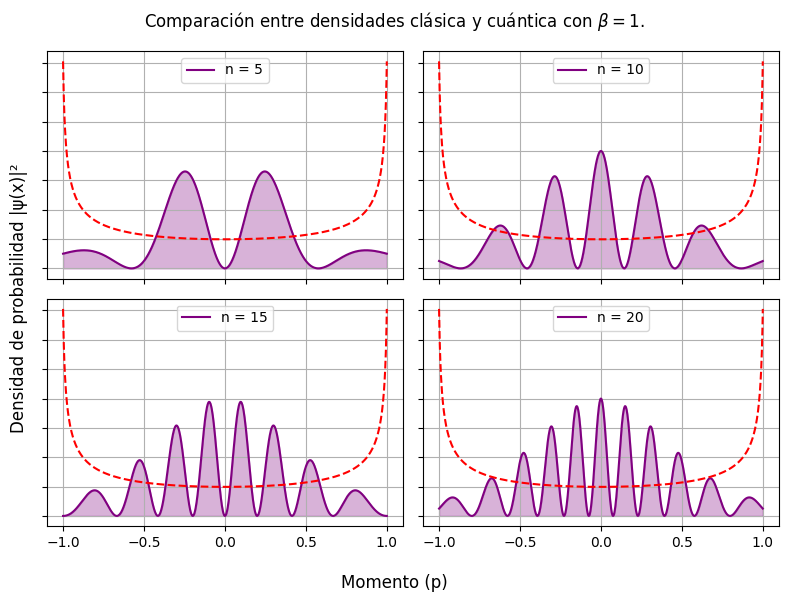

In [20]:
gam = 2
beta = 1
lamb = gam / beta
delta = lamb
alpha = delta - beta
x = np.linspace(-1, 1, 1000)
x2 = np.linspace(-1, 1, 1000)

H1 = gegenbauer(5, alpha, monic=False)
H2 = gegenbauer(10, alpha, monic=False)
H3 = gegenbauer(15, alpha, monic=False)
H4 = gegenbauer(20, alpha, monic=False)
pdf1 = 0.25 / (np.sqrt((1.01) ** 2 - x2**2))
pdf2 = 0.25 / (np.sqrt((1.01) ** 2 - x2**2))
pdf3 = 0.25/ (np.sqrt((1.01) ** 2 - x2**2))
pdf4 = 0.25 / (np.sqrt((1.01) ** 2 - x2**2))

psi1 = (1 + beta * x ** 2) ** (- delta) * H1(x / np.sqrt(1 + beta * x ** 2)) 
psi2 = (1 + beta * x ** 2) ** (- delta) *H2(x / np.sqrt(1 + beta * x ** 2)) 
psi3 = (1 + beta * x ** 2) ** (- delta) *H3(x / np.sqrt(1 + beta * x ** 2)) 
psi4 = (1 + beta * x ** 2) ** (- delta) *H4(x / np.sqrt(1 + beta * x ** 2)) 
densidad1 = psi1**2
densidad2 = psi2**2
densidad3 = psi3**2
densidad4 = psi4**2

fig, ax = plt.subplots(2,2, figsize = (8, 6), sharex = True)
fig.supylabel('Densidad de probabilidad |ψ(x)|²')
fig.suptitle(r'Comparación entre densidades clásica y cuántica con $\beta = 1$.')
fig.supxlabel('Momento (p)')
ax[0, 0].plot(x, densidad1, color='purple', label = 'n = 5')
ax[0, 0].plot(x, pdf1, '--', color = 'red')
ax[0, 0].grid(True)
ax[0, 0].legend()
ax[0, 0].tick_params(labelleft = False)
ax[0, 0].fill_between(x, densidad1, alpha=0.3, color='purple')
ax[0, 1].plot(x, densidad2, color='purple', label = 'n = 10')
ax[0, 1].plot(x, pdf2, '--', color = 'red')
ax[0, 1].grid(True)
ax[0, 1].tick_params(labelleft = False)
ax[0, 1].legend()
ax[0, 1].fill_between(x, densidad2, alpha=0.3, color='purple')
ax[1, 0].plot(x, densidad3, color='purple', label = 'n = 15')
ax[1, 0].plot(x, pdf3, '--', color = 'red')
ax[1, 0].grid(True)
ax[1, 0].legend()
ax[1, 0].tick_params(labelleft = False)
ax[1, 0].fill_between(x, densidad3, alpha=0.3, color='purple')
ax[1, 1].plot(x, densidad4, color='purple', label = 'n = 20')
ax[1, 1].plot(x, pdf4, '--', color = 'red')
ax[1, 1].grid(True)
ax[1, 1].tick_params(labelleft = False)
ax[1, 1].legend()
ax[1, 1].fill_between(x, densidad4, alpha=0.3, color='purple')
plt.tight_layout()
"""
plt.plot(x, densidad, color='purple')
plt.plot(x, pdf, '--', color = 'red', )

plt.title('Densidad de probabilidad del oscilador cuántico (n = 5)')
plt.xlabel('Momento (p)')
plt.ylabel('Densidad de probabilidad |ψ(x)|²')
plt.grid(True)
plt.fill_between(x, densidad, alpha=0.3, color='purple')
"""
plt.show()

In [ ]:
n = 20
gam = 2
beta = 0.5
lamb = gam / beta
delta = lamb
alpha = delta - beta
x = np.linspace(-1, 1, 1000)
psi1 = (1 + beta * x ** 2) ** (- delta) * H1(x / np.sqrt(1 + beta * x ** 2)) 
